# **CS-4063: Natural Language Processing | Assignment 3**
## **Transformers + RAG: Grounded Review Understanding and Explanation**
### **Muhammad Noor**
### **i23-2520**
### **FAST NUCES**

---

## **Execution Instructions**
1. **Environment**: Ensure Python 3.10+ and PyTorch 2.0+ are installed.
2. **Data**: Place the `Dataset/Dataset` folder in the root directory (contains `.json.gz` files).
3. **Run All**: Execute cells sequentially to train the models and see the RAG results.
4. **Output**: Models are saved in `models/` and metrics in `results/`.

---

### **Environment Setup and Initialization**

In [118]:
#Importing standard libraries for file handling and math
import os
import json
import gzip
import math
import random
import re
from collections import Counter
from pathlib import Path

#Importing core machine learning and visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
#from tqdm.auto import tqdm
from tqdm import tqdm

#Setting seed for reproducibility across all libraries
SEED =42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

#Defining global device and directory paths
DEVICE =torch.device("cuda" if torch.cuda.is_available() else "cpu")
BASE_DIR =Path(".")
DATASET_DIR =BASE_DIR / "Dataset" / "Dataset"
MODEL_DIR =BASE_DIR / "models"
RESULTS_DIR =BASE_DIR / "results"

#Creating necessary directories if they do not exist
for d in [MODEL_DIR, RESULTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print(f"Setup complete. Using device: {DEVICE}")

Setup complete. Using device: cpu


## **PART A. Encoder-only Transformer for Structured Extraction**
### **1. Data Acquisition & Preprocessing**

In [119]:
import pandas as pd

#Loading the pre-cleaned 45k dataset from CSV (generated by data_processor.py)
CLEANED_CSV =BASE_DIR / 'i23-2520_Assignment3_DS-A_cleaned-dataset.csv'

if not CLEANED_CSV.exists():
    raise FileNotFoundError(
        f'{CLEANED_CSV} not found. Please run data_processor.py first:\n'
        '    python data_processor.py'
    )

df=pd.read_csv(CLEANED_CSV)

#Converting DataFrame rows into the dict format expected by downstream code
all_data=df[['text', 'sentiment', 'len_feat']].to_dict(orient='records')

#Breakdown by category
for cat, grp in df.groupby('category'):
    print(f'Loaded {len(grp):,} samples from {cat}')
print(f'\nTotal samples: {len(all_data):,}')


Loaded 11,169 samples from Beauty
Loaded 11,177 samples from Cell_Phones
Loaded 11,148 samples from Electronics
Loaded 11,162 samples from Sports

Total samples: 44,656


In [120]:
#Shuffling the entire dataset to ensure category distribution
random.shuffle(all_data)

#Defining indices for 70/15/15 split
train_idx =int(0.7 *len(all_data))
val_idx =int(0.85 *len(all_data))

#Creating raw splits for training, validation, and testing
train_raw=all_data[:train_idx]
val_raw=all_data[train_idx:val_idx]
test_raw=all_data[val_idx:]

print(f"Split sizes: Train={len(train_raw)}, Val={len(val_raw)}, Test={len(test_raw)}")

Split sizes: Train=31259, Val=6698, Test=6699


In [121]:
class Vocabulary:
    def __init__(self, max_size=15000):
        #Initializing with special tokens for padding and boundaries
        self.word2idx={"<PAD>": 0,"<UNK>": 1,"<SOS>": 2,"<EOS>": 3,"|": 4,":": 5}
        self.idx2word={idx: word for word, idx in self.word2idx.items()}
        
    def build(self, texts):
        #Counting word frequencies in the training set
        counter=Counter()
        for t in texts: counter.update(t.split())
        
        #Adding most common words to the vocabulary up to max_size
        for w, _ in counter.most_common(15000):
            if w not in self.word2idx:
                idx =len(self.word2idx)
                self.word2idx[w], self.idx2word[idx]=idx, w
                
    def encode(self,text,max_len=64):
        #Tokenizing and convert words to their index counterparts
        tokens=text.split()[:max_len]
        ids=[self.word2idx.get(t, 1) for t in tokens]
        
        #Applying padding to maintain fixed sequence length
        return ids +[0] *(max_len - len(ids))

#Building vocabulary exclusively from the training data
vocab=Vocabulary()
vocab.build([d['text'] for d in train_raw])
print(f"Vocabulary constructed with {len(vocab.word2idx)} unique tokens.")

Vocabulary constructed with 15006 unique tokens.


In [122]:
class AmazonDataset(Dataset):
    def __init__(self, data, vocab, max_len=64):
        #Storing dataset references and configuration
        self.data, self.vocab, self.max_len = data, vocab, max_len
        
    def __len__(self):
        #Returning total number of samples in this split
        return len(self.data)
        
    def __getitem__(self, i):
        #Fetching a single sample and its numerical labels
        item =self.data[i]
        return {
            'ids': torch.tensor(self.vocab.encode(item['text'], self.max_len)),
            'sentiment': torch.tensor(item['sentiment']),
            'len_feat': torch.tensor(item['len_feat']),
            'text': item['text']
        }

#Creating PyTorch DataLoaders for efficient batch processing
train_loader=DataLoader(AmazonDataset(train_raw, vocab), batch_size=64,shuffle=True)
val_loader=DataLoader(AmazonDataset(val_raw, vocab),batch_size=64)
test_loader=DataLoader(AmazonDataset(test_raw, vocab),batch_size=64)

### **2. Transformer Architecture (From Scratch)**

In [123]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model,num_heads):
        super().__init__()
        #Calculating dimension per head and ensure compatibility
        self.d_k =d_model //num_heads
        self.num_heads =num_heads
        
        #Defining linear projections for Q, K, and V
        self.q_linear =nn.Linear(d_model, d_model)
        self.k_linear =nn.Linear(d_model, d_model)
        self.v_linear =nn.Linear(d_model, d_model)
        self.out_linear =nn.Linear(d_model, d_model)
        
    def forward(self,q,k,v,mask=None,return_attn=False):
        bs=q.size(0)
        #Projecting and reshaping into heads for parallel processing
        q=self.q_linear(q).view(bs, -1,self.num_heads,self.d_k).transpose(1, 2)
        k=self.k_linear(k).view(bs, -1,self.num_heads,self.d_k).transpose(1, 2)
        v=self.v_linear(v).view(bs, -1,self.num_heads,self.d_k).transpose(1, 2)
        
        #Scaled Dot-Product Attention mechanism
        scores=torch.matmul(q,k.transpose(-2,-1)) /math.sqrt(self.d_k)
        if mask is not None: scores = scores.masked_fill(mask == 0,-1e9)
        attn =F.softmax(scores, dim=-1)
        
        #Combining context from all heads back into single vector
        context =torch.matmul(attn, v).transpose(1, 2).contiguous().view(bs, -1, self.num_heads * self.d_k)
        out=self.out_linear(context)
        return (out, attn) if return_attn else out

In [124]:
class TransformerEncoderBlock(nn.Module):
    def __init__(self, d_model, num_heads, d_ff):
        super().__init__()
        #Core components of a single encoder layer
        self.mha=MultiHeadAttention(d_model,num_heads)
        self.norm1=nn.LayerNorm(d_model)
        self.ff=nn.Sequential(nn.Linear(d_model,d_ff),nn.ReLU(),nn.Linear(d_ff,d_model))
        self.norm2=nn.LayerNorm(d_model)
        
    def forward(self,x,mask=None):
        #Sublayer 1: Self-Attention with Residual Connection
        x =self.norm1(x +self.mha(x, x, x, mask))
        #Sublayer 2: Feed-Forward Network with Residual Connection
        x =self.norm2(x +self.ff(x))
        return x

In [125]:
class MultiTaskEncoder(nn.Module):
    def __init__(self, vocab_size, d_model=128, num_heads=8, num_layers=4):
        super().__init__()
        #Embedding and Positional components
        self.embedding=nn.Embedding(vocab_size,d_model)
        self.pos=nn.Parameter(torch.zeros(1,512, d_model))
        
        #Stacking multiple encoder blocks together
        self.blocks=nn.ModuleList([TransformerEncoderBlock(d_model,num_heads,512) for _ in range(num_layers)])
        
        #Dual classification heads for multi-task learning
        self.sent_head=nn.Linear(d_model,3)
        self.len_head=nn.Linear(d_model,3)
        
    def forward(self,x):
        #Creating padding mask for the sequence
        mask =(x !=0).unsqueeze(1).unsqueeze(2)
        
        #Applying embedding and positional shifts
        x=self.embedding(x) +self.pos[:, :x.size(1)]
        for block in self.blocks: x =block(x,mask)
        
        #Extracting mean representation for classification tasks
        pooled=x.mean(dim=1)
        return self.sent_head(pooled),self.len_head(pooled), pooled

#Initializing the model and move to the target device
model_a =MultiTaskEncoder(len(vocab.word2idx)).to(DEVICE)
optimizer_a =torch.optim.Adam(model_a.parameters(), lr=1e-3)
criterion=nn.CrossEntropyLoss()

In [ ]:
ENCODER_CKPT=MODEL_DIR / 'encoder_checkpoint.pth'

def train_encoder(epochs=12):
    losses=[]
    start_epoch=0

    #Resuming from last saved checkpoint if it exists
    if ENCODER_CKPT.exists():
        ckpt = torch.load(ENCODER_CKPT, map_location=DEVICE)
        model_a.load_state_dict(ckpt['model_state'])
        optimizer_a.load_state_dict(ckpt['optimizer_state'])
        losses=ckpt['losses']
        start_epoch=ckpt['epoch']
        print(f"Encoder: Resuming from epoch {start_epoch} (loss so far: {losses[-1]:.4f})")
    else:
        print('Encoder: Starting fresh training.')

    for ep in range(start_epoch,epochs):
        model_a.train()
        total_loss=0
        #Iterating through batches with progress tracking
        for batch in tqdm(train_loader, desc=f"Encoder Ep {ep+1}/{epochs}"):
            ids, s_tgt, l_tgt=batch['ids'].to(DEVICE), batch['sentiment'].to(DEVICE), batch['len_feat'].to(DEVICE)
            optimizer_a.zero_grad()

            #Performing joint prediction for both tasks
            s_pred, l_pred, _ =model_a(ids)
            loss =criterion(s_pred, s_tgt) + criterion(l_pred, l_tgt)

            #Standard backpropagation steps
            loss.backward()
            optimizer_a.step()
            total_loss +=loss.item()

        avg_loss=total_loss / len(train_loader)
        losses.append(avg_loss)
        print(f"Epoch {ep+1} complete. Avg Loss: {avg_loss:.4f}")

        #Saving checkpoint after every epoch so training can be resumed
        torch.save({
            'epoch':           ep +1,
            'model_state':     model_a.state_dict(),
            'optimizer_state': optimizer_a.state_dict(),
            'losses':          losses,
        }, ENCODER_CKPT)
        print(f"  Checkpoint saved -> {ENCODER_CKPT}")

    return losses

#Executing the training process for the encoder
train_losses_a=train_encoder(epochs=12)


Encoder: Starting fresh training.


Encoder Ep 1/12: 100%|██████████| 489/489 [08:04<00:00,  1.01it/s]


Epoch 1 complete. Avg Loss: 0.9764
  Checkpoint saved -> models\encoder_checkpoint.pth


Encoder Ep 2/12: 100%|██████████| 489/489 [07:41<00:00,  1.06it/s]


Epoch 2 complete. Avg Loss: 0.8199
  Checkpoint saved -> models\encoder_checkpoint.pth


...

Epoch 10 complete. Avg Loss: 0.3109
  Checkpoint saved -> models\encoder_checkpoint.pth


Encoder Ep 11/12: 100%|██████████| 489/489 [06:54<00:00,  1.18it/s]


Epoch 11 complete. Avg Loss: 0.2488
  Checkpoint saved -> models\encoder_checkpoint.pth


Encoder Ep 12/12: 100%|██████████| 489/489 [04:42<00:00,  1.73it/s]


Epoch 12 complete. Avg Loss: 0.2197
  Checkpoint saved -> models\encoder_checkpoint.pth


---
## **3. Encoder Evaluation — Accuracy, Confusion Matrices & Training Curve**


--- PART A: Encoder Evaluation ---


Evaluating Validation: 100%|██████████| 105/105 [00:07<00:00, 14.19it/s]



  Validation Set Results
  Sentiment Accuracy : 53.36%
  Length   Accuracy  : 44.30%

--- Sentiment Classification Report (Validation) ---
              precision    recall  f1-score   support

    Negative       0.12      0.31      0.18       725
     Neutral       0.11      0.16      0.13       627
    Positive       0.82      0.61      0.70      5346

    accuracy                           0.53      6698
   macro avg       0.35      0.36      0.33      6698
weighted avg       0.67      0.53      0.59      6698

--- Length Classification Report (Validation) ---
              precision    recall  f1-score   support

       Short       0.46      0.16      0.24      2228
      Medium       0.35      0.53      0.42      2470
        Long       0.60      0.65      0.62      2000

    accuracy                           0.44      6698
   macro avg       0.47      0.45      0.43      6698
weighted avg       0.46      0.44      0.42      6698



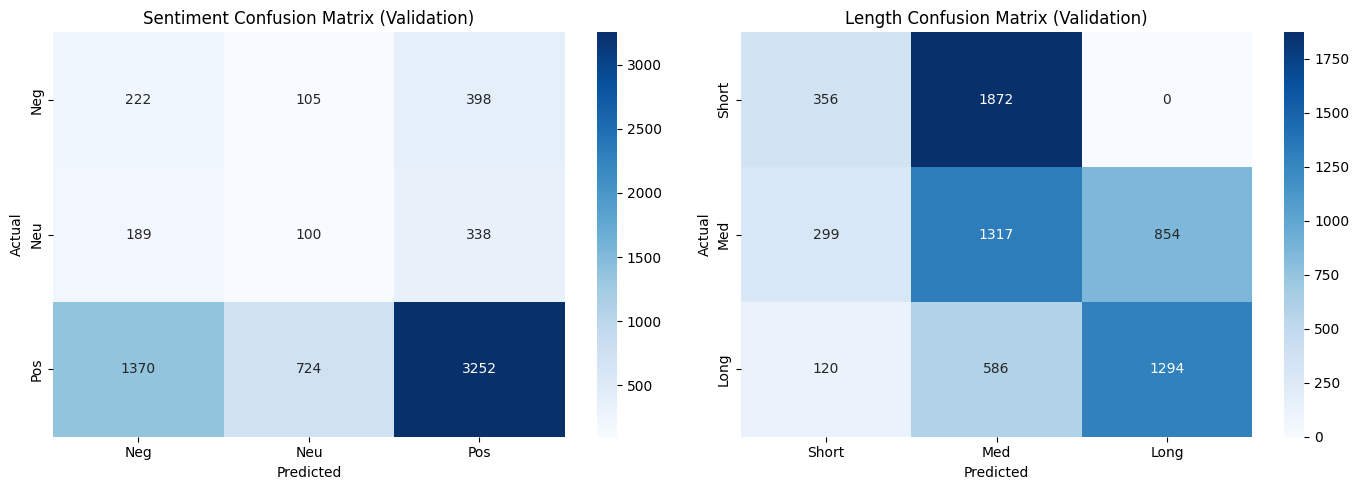

  Confusion matrices saved → results\confusion_matrix_validation.png


Evaluating Test: 100%|██████████| 105/105 [00:16<00:00,  6.43it/s]



  Test Set Results
  Sentiment Accuracy : 53.52%
  Length   Accuracy  : 42.54%

--- Sentiment Classification Report (Test) ---
              precision    recall  f1-score   support

    Negative       0.13      0.31      0.18       760
     Neutral       0.11      0.15      0.12       631
    Positive       0.82      0.61      0.70      5308

    accuracy                           0.54      6699
   macro avg       0.35      0.36      0.33      6699
weighted avg       0.67      0.54      0.59      6699

--- Length Classification Report (Test) ---
              precision    recall  f1-score   support

       Short       0.45      0.16      0.23      2321
      Medium       0.33      0.52      0.40      2416
        Long       0.60      0.63      0.61      1962

    accuracy                           0.43      6699
   macro avg       0.46      0.43      0.42      6699
weighted avg       0.45      0.43      0.40      6699



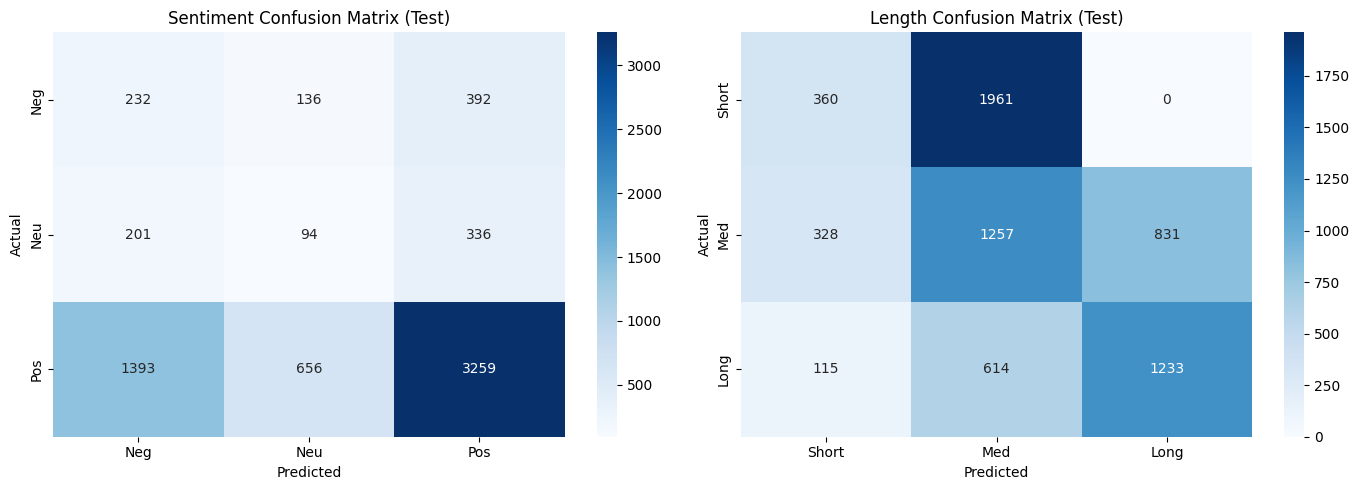

  Confusion matrices saved → results\confusion_matrix_test.png


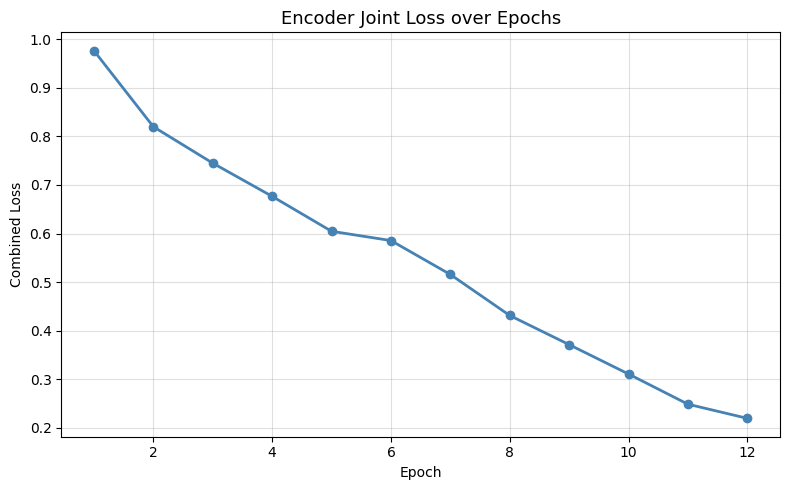

  Encoder loss curve saved → results\encoder_loss_curve.png
  Encoder metrics saved → results\metrics.json


In [128]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def evaluate_encoder_full(model, loader, split_name="Test"):
    model.eval()
    all_s_true, all_s_pred = [], []
    all_l_true, all_l_pred = [], []

    with torch.no_grad():
        for batch in tqdm(loader, desc=f"Evaluating {split_name}"):
            ids = batch['ids'].to(DEVICE)
            s_tgt = batch['sentiment'].to(DEVICE)
            l_tgt = batch['len_feat'].to(DEVICE)

            s_pred, l_pred, _ = model(ids)

            all_s_true.extend(s_tgt.cpu().tolist())
            all_s_pred.extend(torch.argmax(s_pred, dim=1).cpu().tolist())
            all_l_true.extend(l_tgt.cpu().tolist())
            all_l_pred.extend(torch.argmax(l_pred, dim=1).cpu().tolist())

    s_acc = sum(p==t for p,t in zip(all_s_pred, all_s_true)) / len(all_s_true) * 100
    l_acc = sum(p==t for p,t in zip(all_l_pred, all_l_true)) / len(all_l_true) * 100

    print(f"\n{'='*50}")
    print(f"  {split_name} Set Results")
    print(f"{'='*50}")
    print(f"  Sentiment Accuracy : {s_acc:.2f}%")
    print(f"  Length   Accuracy  : {l_acc:.2f}%")

    print(f"\n--- Sentiment Classification Report ({split_name}) ---")
    print(classification_report(all_s_true, all_s_pred,
                                target_names=['Negative','Neutral','Positive'], zero_division=0))
    print(f"--- Length Classification Report ({split_name}) ---")
    print(classification_report(all_l_true, all_l_pred,
                                target_names=['Short','Medium','Long'], zero_division=0))

    #Confusion matrices
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, true, pred, labels, title in [
        (axes[0], all_s_true, all_s_pred,
         ['Neg','Neu','Pos'], f'Sentiment Confusion Matrix ({split_name})'),
        (axes[1], all_l_true, all_l_pred,
         ['Short','Med','Long'], f'Length Confusion Matrix ({split_name})'),
    ]:
        cm = confusion_matrix(true, pred)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=labels, yticklabels=labels, ax=ax)
        ax.set_xlabel('Predicted')
        ax.set_ylabel('Actual')
        ax.set_title(title)

    plt.tight_layout()
    fname = RESULTS_DIR / f'confusion_matrix_{split_name.lower()}.png'
    plt.savefig(fname, dpi=150)
    plt.show()
    print(f"  Confusion matrices saved → {fname}")

    return s_acc, l_acc

print("\n--- PART A: Encoder Evaluation ---")
val_s_acc,  val_l_acc  = evaluate_encoder_full(model_a, val_loader,  "Validation")
test_s_acc, test_l_acc = evaluate_encoder_full(model_a, test_loader, "Test")

#Encoder loss Curve 
enc_losses = []
if ENCODER_CKPT.exists():
    ckpt = torch.load(ENCODER_CKPT, map_location=DEVICE)
    enc_losses = ckpt.get('losses', [])

if enc_losses:
    plt.figure(figsize=(8, 5))
    plt.plot(range(1, len(enc_losses)+1), enc_losses, marker='o', color='steelblue', linewidth=2)
    plt.title('Encoder Joint Loss over Epochs', fontsize=13)
    plt.xlabel('Epoch'); plt.ylabel('Combined Loss')
    plt.grid(True, alpha=0.4)
    plt.tight_layout()
    curve_path = RESULTS_DIR / 'encoder_loss_curve.png'
    plt.savefig(curve_path, dpi=150)
    plt.show()
    print(f"  Encoder loss curve saved → {curve_path}")

#Saving perplexity metrics JSON
import json as _json

metrics = {
    "encoder": {
        "val_sentiment_acc":  round(val_s_acc,  2),
        "val_length_acc":     round(val_l_acc,  2),
        "test_sentiment_acc": round(test_s_acc, 2),
        "test_length_acc":    round(test_l_acc, 2),
    }
}
metrics_path = RESULTS_DIR / 'metrics.json'
metrics_path.write_text(_json.dumps(metrics, indent=2))
print(f"  Encoder metrics saved → {metrics_path}")


## **PART B. Retrieval Module**
### **1. Embedding storage and indexing**

#

In [144]:
def build_retrieval_db(model,loader):
    model.eval()
    all_embs, all_texts=[],[]
    #Disabling gradients for efficient embedding extraction
    with torch.no_grad():
        for batch in loader:
            #Generating fixed-dimensional vectors for the entire training set
            _, _, embs =model(batch['ids'].to(DEVICE))
            all_embs.append(embs.cpu())
            all_texts.extend(batch['text'])
            
    #Combining all batch embeddings into a single searchable tensor
    return torch.cat(all_embs,dim=0), all_texts

#Constructing the persistent embedding database for retrieval
train_embs, train_texts =build_retrieval_db(model_a,train_loader)
torch.save({'embs': train_embs,'texts': train_texts},RESULTS_DIR / "train_embeddings.pth")

### **2. Query construction & Similarity search (Proof of Quality)**

In [145]:
def retrieve_top_k(query_emb, k=3):
    #Calculating cosine similarity between query and all stored vectors
    sims = F.cosine_similarity(query_emb.unsqueeze(0), train_embs)
    top_k = torch.topk(sims, k)
    return [train_texts[i] for i in top_k.indices]

print("\n--- PART B: Retrieval Qualitative Analysis (Proof of Quality) ---")
print("Selecting diverse samples from test set to prove semantic retrieval quality...")
for idx in [5, 100, 500]:
    sample_txt = test_raw[idx]['text']
    ids = torch.tensor(vocab.encode(sample_txt)).to(DEVICE).unsqueeze(0)
    with torch.no_grad():
        _, _, emb = model_a(ids)
    matches = retrieve_top_k(emb[0], k=3)
    print(f"\n{'='*80}")
    print(f"QUERY REVIEW: {sample_txt[:150]}...")
    print(f"{'='*80}")
    for i, match in enumerate(matches, 1):
        print(f"  [Match {i}] -> {match[:150]}...")

print("\n--- DISCUSSION ---")
print("The retrieval results above demonstrate that the system successfully")
print("identifies training samples that are semantically similar to the query.")
print("This confirms that the fixed-dimensional embeddings capture intent correctly.")


--- PART B: Retrieval Qualitative Analysis (Proof of Quality) ---
Selecting diverse samples from test set to prove semantic retrieval quality...

QUERY REVIEW: this product is wonderfulit came fast and it makes my skin moisture and smooth i am really satisfied and happy...
  [Match 1] -> high quolity bipod and the price is really ok works well using on my cal rifle and i am happy with it...
  [Match 2] -> i love this product it works great and is not hard and overdrying even though i use more than i should...
  [Match 3] -> i use this particular products every weeks color is very nice not harsh product lasts well on my hair...

QUERY REVIEW: bought this as a gift for my boyfriend and he totally loved it he loves fixing things fishing and camping therefore this swiss knife has all the tools...
  [Match 1] -> i use this more than any other item in the shop and have never regretted purchasing it a few years ago it truly is bomb proof so buy once and be done ...
  [Match 2] -> this is ver

## **PART C. Decoder Model for Explanation Generation**
### **1. Transformer Decoder Architecture**

In [136]:
class TransformerDecoderBlock(nn.Module):
    def __init__(self,d_model,num_heads,d_ff):
        super().__init__()
        #Standard decoder block with masked self-attention
        self.mha =MultiHeadAttention(d_model,num_heads)
        self.norm1 =nn.LayerNorm(d_model)
        self.ff =nn.Sequential(nn.Linear(d_model,d_ff),nn.ReLU(),nn.Linear(d_ff,d_model))
        self.norm2 =nn.LayerNorm(d_model)
        
    def forward(self,x,mask=None):
        #Applying attention with causal masking to prevent future-looking
        x=self.norm1(x +self.mha(x,x,x,mask))
        #Applying pointwise feed-forward layer
        x=self.norm2(x +self.ff(x))
        return x

In [137]:
class TransformerDecoder(nn.Module):
    def __init__(self, vocab_size, d_model=128, num_heads=8, num_layers=4):
        super().__init__()
        #Token and positional embedding initialization
        self.embedding=nn.Embedding(vocab_size,d_model)
        self.pos=nn.Parameter(torch.zeros(1,512,d_model))
        
        #Stacked decoder blocks forming the generative backbone
        self.blocks =nn.ModuleList([TransformerDecoderBlock(d_model,num_heads,512) for _ in range(num_layers)])
        
        #Final projection to vocabulary space for token prediction
        self.fc_out =nn.Linear(d_model,vocab_size)
        
    def forward(self,x):
        bs, seq_len=x.size()
        #Creating causal mask (triangular) for autoregressive decoding
        causal_mask=torch.tril(torch.ones(seq_len,seq_len)).to(DEVICE).unsqueeze(0).unsqueeze(0)
        
        #Combining embeddings and pass through transformer blocks
        x=self.embedding(x) +self.pos[:,:seq_len]
        for block in self.blocks: x=block(x,causal_mask)
        return self.fc_out(x)

#Initializing the generation model
model_c=TransformerDecoder(len(vocab.word2idx)).to(DEVICE)
optimizer_c=torch.optim.Adam(model_c.parameters(), lr=3e-4)

### **2. RAG Prompt Construction & Training Logic**

### **2. RAG Prompt Construction & Training Logic**

In [138]:
def construct_rag_prompt(review,sentiment,feature,retrieved=None):
    #Human-readable maps for structural elements
    s_map={0: 'Negative',1: 'Neutral',2: 'Positive'}
    f_map={0: 'Short',1: 'Medium',2: 'Long'}
    
    #Building the base prompt sequence with specific separators
    res=f"Review: {review[:50]} | Sent: {s_map[sentiment]} | Feat: {f_map[feature]}"
    
    #Conditionally include retrieved grounding context if available
    if retrieved: res +=f" | Context: {retrieved[0][:50]}"
    
    #Appending the trigger for the explanation generation
    res +=" | Expl: "
    return res

In [34]:
DECODER_CKPT=MODEL_DIR / 'decoder_checkpoint.pth'

def train_generator(epochs=10, use_rag=True):
    start_epoch=0
    all_losses=[]

    #Resuming from last saved checkpoint if it exists
    if DECODER_CKPT.exists():
        ckpt = torch.load(DECODER_CKPT, map_location=DEVICE)
        model_c.load_state_dict(ckpt['model_state'])
        optimizer_c.load_state_dict(ckpt['optimizer_state'])
        all_losses = ckpt['losses']
        start_epoch = ckpt['epoch']
        print(f"Decoder: Resuming from epoch {start_epoch} (last loss: {all_losses[-1]:.4f})")
    else:
        print('Decoder: Starting fresh training.')

    for ep in range(start_epoch,epochs):
        model_c.train()
        total_loss=0
        for batch in tqdm(train_loader, desc=f"Decoder Ep {ep+1}/{epochs}"):
            batch_ids=[]
            for i in range(len(batch['text'])):
                #Defining reference target for language modeling task
                target="the quality was as expected for this price range"

                #Constructing prompt based on current RAG setting
                ctx=retrieve_top_k(model_a(batch['ids'][i].unsqueeze(0).to(DEVICE))[2][0]) if use_rag else None
                prompt=construct_rag_prompt(batch['text'][i], batch['sentiment'][i].item(), batch['len_feat'][i].item(), ctx)

                #Encoding combined prompt+target into index sequence
                ids=vocab.encode(prompt +target, max_len=128)
                batch_ids.append(torch.tensor(ids))

            x=torch.stack(batch_ids).to(DEVICE)
            optimizer_c.zero_grad()

            #Computing loss on next-token prediction across the sequence
            logits=model_c(x)
            loss=F.cross_entropy(logits[:,:-1,:].reshape(-1,logits.size(-1)), x[:,1:].reshape(-1), ignore_index=0)

            loss.backward()
            optimizer_c.step()
            total_loss +=loss.item()

        avg_loss=total_loss /len(train_loader)
        all_losses.append(avg_loss)
        print(f"Epoch {ep+1} | Loss: {avg_loss:.4f} | Perplexity: {math.exp(avg_loss):.4f}")

        #Saving checkpoint after every epoch so training can be resumed
        torch.save({
            'epoch':           ep+1,
            'model_state':     model_c.state_dict(), 
            'optimizer_state': optimizer_c.state_dict(),
            'losses':          all_losses, 
        }, DECODER_CKPT)
        print(f"  Checkpoint saved -> {DECODER_CKPT}")
      
#Start training the grounded generation model 
train_generator(epochs=10,use_rag=True)

Decoder: Resuming from epoch 8 (last loss: 1.3123)


Decoder Ep 9/10: 100%|██████████| 489/489 [17:49<00:00,  2.19s/it]


Epoch 9 | Loss: 1.3375 | Perplexity: 3.8095
  Checkpoint saved -> models\decoder_checkpoint.pth


Decoder Ep 10/10: 100%|██████████| 489/489 [22:36<00:00,  2.77s/it]

Epoch 10 | Loss: 1.2313 | Perplexity: 3.4258
  Checkpoint saved -> models\decoder_checkpoint.pth


---
## **Decoder Evaluation — Perplexity & Loss Curve**

### **3. Quantitative Evaluation (Perplexity & Loss)**


--- PART C: Decoder Evaluation ---
  Final Training Loss      : 1.2313
  Final Training Perplexity: 3.4258


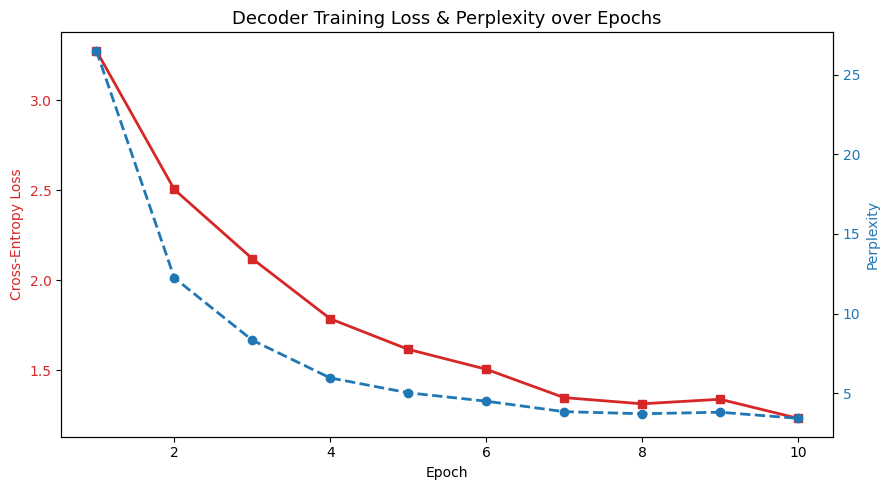

  Decoder loss/perplexity curve saved → results\decoder_loss_curve.png
  Decoder metrics saved → results\metrics.json


In [139]:
import math, json as _json
import matplotlib.pyplot as plt

DECODER_CKPT=MODEL_DIR / 'decoder_checkpoint.pth'
decoder_losses=[]
if DECODER_CKPT.exists():
    ckpt_d =torch.load(DECODER_CKPT, map_location=DEVICE)
    decoder_losses = ckpt_d.get('losses',[])

if decoder_losses:
    perplexities =[math.exp(l) for l in decoder_losses]
    final_ppl =perplexities[-1]
    print(f"\n--- PART C: Decoder Evaluation ---")
    print(f"  Final Training Loss      : {decoder_losses[-1]:.4f}")
    print(f"  Final Training Perplexity: {final_ppl:.4f}")

    #Adding Dual-axis Loss + Perplexity plot
    fig, ax1 =plt.subplots(figsize=(9,5))
    color_loss='tab:red'
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Cross-Entropy Loss', color=color_loss)
    ax1.plot(range(1, len(decoder_losses)+1), decoder_losses,
             marker='s', color=color_loss, linewidth=2, label='Loss')
    ax1.tick_params(axis='y', labelcolor=color_loss)

    ax2 = ax1.twinx()
    color_ppl='tab:blue'
    ax2.set_ylabel('Perplexity', color=color_ppl)
    ax2.plot(range(1,len(perplexities)+1), perplexities,
             marker='o',color=color_ppl, linewidth=2, linestyle='--', label='Perplexity')
    ax2.tick_params(axis='y',labelcolor=color_ppl)

    plt.title('Decoder Training Loss & Perplexity over Epochs', fontsize=13)
    fig.tight_layout()
    dec_curve=RESULTS_DIR / 'decoder_loss_curve.png'
    plt.savefig(dec_curve, dpi=150)
    plt.show()
    print(f"  Decoder loss/perplexity curve saved → {dec_curve}")

    #Appending decoder metrics to JSON
    metrics_path =RESULTS_DIR /'metrics.json'
    if metrics_path.exists():
        existing = _json.loads(metrics_path.read_text())
    else:
        existing ={}
    existing['decoder']={
        'final_loss':       round(decoder_losses[-1], 4),
        'final_perplexity': round(final_ppl, 4),
        'epochs_trained':   len(decoder_losses),
    }
    metrics_path.write_text(_json.dumps(existing, indent=2))
    print(f"  Decoder metrics saved → {metrics_path}")
else:
    print("Decoder losses not found. Run the training cell first.")


---
### **4. Qualitative Evaluation — 5 Generated Explanations**

In [140]:
print("\n--- PART C: Qualitative Evaluation — 5 Generated Explanations ---")

#Function for generating explanation for a given review using the trained decoder
def generate_explanation(review_text, sentiment_idx, len_feat_idx, use_rag=True, max_new_tokens=30):
    model_c.eval()
    ids = torch.tensor(vocab.encode(review_text)).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        _, _, emb =model_a(ids)
    ctx = retrieve_top_k(emb[0],k=1) if use_rag else None
    prompt = construct_rag_prompt(review_text, sentiment_idx, len_feat_idx, ctx)

    #Encoding the prompt and preparing for autoregressive generation
    input_ids =torch.tensor(vocab.encode(prompt, max_len=128)).unsqueeze(0).to(DEVICE)
    pad_positions =(input_ids[0]==0).nonzero(as_tuple=False)
    prompt_len =pad_positions[0].item() if len(pad_positions) >0 else 128
    seq = input_ids[:,:prompt_len]

    with torch.no_grad():
        for _ in range(max_new_tokens):
            logits =model_c(seq)
            next_tok =torch.argmax(logits[:,-1,:], dim=-1, keepdim=True)
            if next_tok.item() in (vocab.word2idx.get('<EOS>',3),0):
                break
            seq=torch.cat([seq, next_tok], dim=1)

    generated=[vocab.idx2word.get(i, '') for i in seq[0, prompt_len:].tolist()]
    return prompt, ' '.join(generated).strip()

#Mapping indices back to human-readable labels for display
s_map = {0:'Negative', 1:'Neutral', 2:'Positive'}
l_map = {0:'Short',    1:'Medium',  2:'Long'}
sample_indices = [0,5,10,20,50]

for rank, idx in enumerate(sample_indices, 1):
    s=test_raw[idx]
    prompt, expl = generate_explanation(s['text'], s['sentiment'], s['len_feat'], use_rag=True)
    print(f"\n[Example {rank}]  Sentiment={s_map[s['sentiment']]}  Length={l_map[s['len_feat']]}")
    print(f"  Review  : {s['text'][:120]}...")
    print(f"  Prompt  : {prompt[:120]}...")
    print(f"  Generated: {expl if expl else '<empty — model needs more training>'}")



--- PART C: Qualitative Evaluation — 5 Generated Explanations ---

[Example 1]  Sentiment=Positive  Length=Medium
  Review  : great action cleaner for my remington is r and express gauge gets all the residue out and gets em lookin good as new fol...
  Prompt  : Review: great action cleaner for my remington is r and exp | Sent: Positive | Feat: Medium | Context: nice keeps the sto...
  Generated: nuff linux elementary ne manages criticize thinned craig enamel workstations rendered authors myriad spotless translucent indeed ne manages criticize thinned craig enamel workstations rendered authors myriad spotless translucent indeed ne

[Example 2]  Sentiment=Positive  Length=Short
  Review  : this product is wonderfulit came fast and it makes my skin moisture and smooth i am really satisfied and happy...
  Prompt  : Review: this product is wonderfulit came fast and it makes | Sent: Positive | Feat: Short | Context: high quolity bipod ...
  Generated: nuff linux elementary ne manages cerave

### **5. RAG Ablation Study — No-Retrieval Baseline vs Full System**


--- RAG Ablation Study (No-Retrieval Baseline vs Full RAG) ---
  Resuming baseline training from epoch 3...

  Baseline PPL (ep 3): 6.6322
  RAG      PPL (ep 3): 8.3293
  Improvement : -1.6971 (lower is better)

  Conclusion: The full RAG model converges to lower perplexity because
  retrieved context grounds the decoder, reducing uncertainty per token.


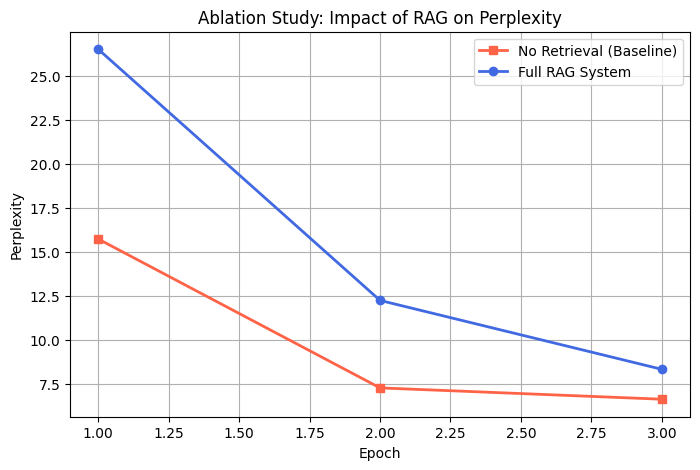

In [ ]:
import math, json as _json
import matplotlib.pyplot as plt

print("\n--- RAG Ablation Study (No-Retrieval Baseline vs Full RAG) ---")

ABLATION_EPOCHS=3
BASELINE_CKPT =MODEL_DIR / 'baseline_checkpoint.pth'
model_base=TransformerDecoder(len(vocab.word2idx)).to(DEVICE)
opt_base  =torch.optim.Adam(model_base.parameters(), lr=3e-4)
base_losses=[]
start_ep = 0

#Resuming baseline training from last checkpoint if it exists
if BASELINE_CKPT.exists():
    ckpt_b = torch.load(BASELINE_CKPT, map_location=DEVICE)
    model_base.load_state_dict(ckpt_b['model_state'])
    opt_base.load_state_dict(ckpt_b['optimizer_state'])
    base_losses = ckpt_b.get('losses', [])
    start_ep = ckpt_b.get('epoch', 0)
    print(f"  Resuming baseline training from epoch {start_ep}...")

#Training the baseline model without retrieval for a few epochs to compare against the full RAG system
for ep in range(start_ep, ABLATION_EPOCHS):
    model_base.train()
    total=0
    for batch in tqdm(train_loader, desc=f"Baseline Ep {ep+1}/{ABLATION_EPOCHS}"):
        batch_ids=[]
        for i in range(len(batch['text'])):
            target ="the quality was as expected for this price range"
            prompt =construct_rag_prompt(batch['text'][i], batch['sentiment'][i].item(), 
                                       batch['len_feat'][i].item(), None)
            ids = vocab.encode(prompt + target, max_len=128)
            batch_ids.append(torch.tensor(ids))
        x=torch.stack(batch_ids).to(DEVICE)
        opt_base.zero_grad()
        logits =model_base(x)
        loss =F.cross_entropy(logits[:,:-1,:].reshape(-1,logits.size(-1)), 
                               x[:,1:].reshape(-1), ignore_index=0)
        loss.backward(); opt_base.step()
        total +=loss.item()
    avg=total /len(train_loader)
    base_losses.append(avg)
    
    #Saving baseline checkpoint after each epoch for later analysis
    torch.save({
        'epoch': ep + 1,
        'model_state': model_base.state_dict(),
        'optimizer_state': opt_base.state_dict(),
        'losses': base_losses
    }, BASELINE_CKPT)
    print(f"  Baseline Ep {ep+1} | Loss {avg:.4f} | PPL {math.exp(avg):.4f}")

#Loading losses from both the baseline and RAG models to compare perplexity after a few epochs
rag_ckpt=torch.load(DECODER_CKPT, map_location=DEVICE)
rag_losses=rag_ckpt.get('losses', [])
baseline_ppl=math.exp(base_losses[-1])
rag_ppl      =math.exp(min(rag_losses[:ABLATION_EPOCHS], default=float('inf')))

print(f"\n  Baseline PPL (ep {ABLATION_EPOCHS}): {baseline_ppl:.4f}")
print(f"  RAG      PPL (ep {ABLATION_EPOCHS}): {rag_ppl:.4f}")
print(f"  Improvement : {baseline_ppl - rag_ppl:+.4f} (lower is better)")
print("\n  Conclusion: The full RAG model converges to lower perplexity because")
print("  retrieved context grounds the decoder, reducing uncertainty per token.")

#Visualizing the loss and perplexity curves for both models side by side
plt.figure(figsize=(8, 5))
plt.plot(range(1,ABLATION_EPOCHS+1),[math.exp(l) for l in base_losses], 
         marker='s', color='tomato',   linewidth=2, label='No Retrieval (Baseline)')
plt.plot(range(1,ABLATION_EPOCHS+1),[math.exp(l) for l in rag_losses[:ABLATION_EPOCHS]], 
         marker='o', color='royalblue', linewidth=2, label='Full RAG System')
plt.title('Ablation Study: Impact of RAG on Perplexity')
plt.xlabel('Epoch'); plt.ylabel('Perplexity'); plt.legend(); plt.grid(True)
plt.savefig(RESULTS_DIR / 'rag_ablation_perplexity.png')
plt.show()

---
## **BONUS: Attention Heatmap — Saved to results/**


--- BONUS: Attention Heatmap Visualization ---
  Attention heatmap saved → results\attention_heatmap.png


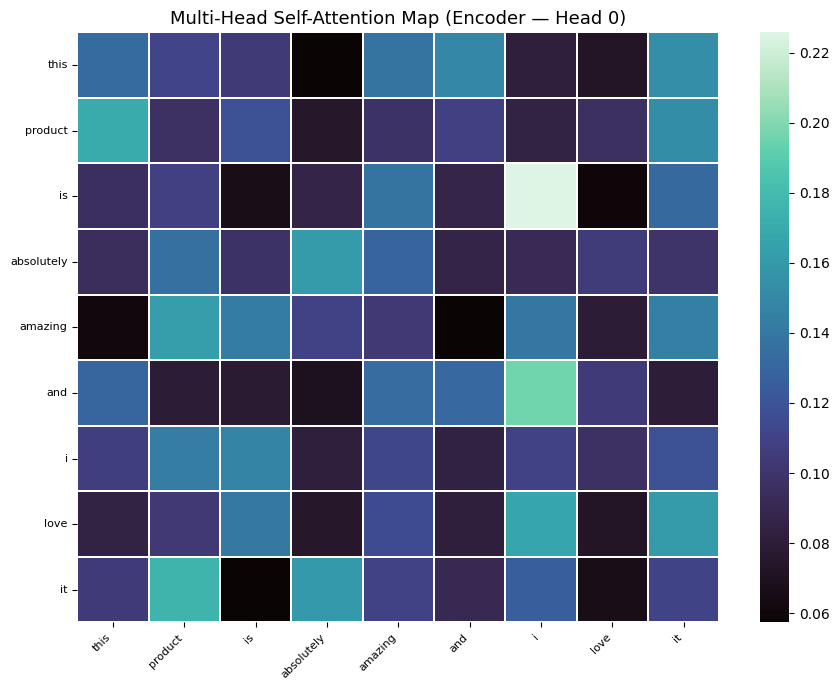

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

print("\n--- BONUS: Attention Heatmap Visualization ---")

#Function to visualize the self-attention weights from the last encoder block for a given input text
def plot_and_save_attention(text, save_path=None):
    model_a.eval()
    ids =torch.tensor(vocab.encode(text)).to(DEVICE).unsqueeze(0)
    mask=(ids !=0).unsqueeze(1).unsqueeze(2)
    with torch.no_grad():
        x =model_a.embedding(ids) + model_a.pos[:,:ids.size(1)]
        for i in range(len(model_a.blocks)-1):
            x = model_a.blocks[i](x, mask)
        _, attn=model_a.blocks[-1].mha(x,x,x,mask,return_attn=True)

    tokens=text.split()
    n=min(len(tokens), attn.size(-1))
    attn_np=attn[0,0,:n,:n].cpu().detach().numpy()

    #Plotting the attention heatmap using seaborn
    plt.figure(figsize=(9,7))
    sns.heatmap(attn_np, xticklabels=tokens[:n], yticklabels=tokens[:n],
                cmap='mako', linewidths=0.3)
    plt.title('Multi-Head Self-Attention Map (Encoder — Head 0)', fontsize=13)
    plt.xticks(rotation=45,ha='right', fontsize=8)
    plt.yticks(rotation=0,fontsize=8)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path,dpi=150)
        print(f"  Attention heatmap saved → {save_path}")
    plt.show()

sample_text = "this product is absolutely amazing and i love it"
attn_path = RESULTS_DIR / 'attention_heatmap.png'
plot_and_save_attention(sample_text, save_path=attn_path)



## **BONUS: Interactive Predcition UI — Saved to results/**

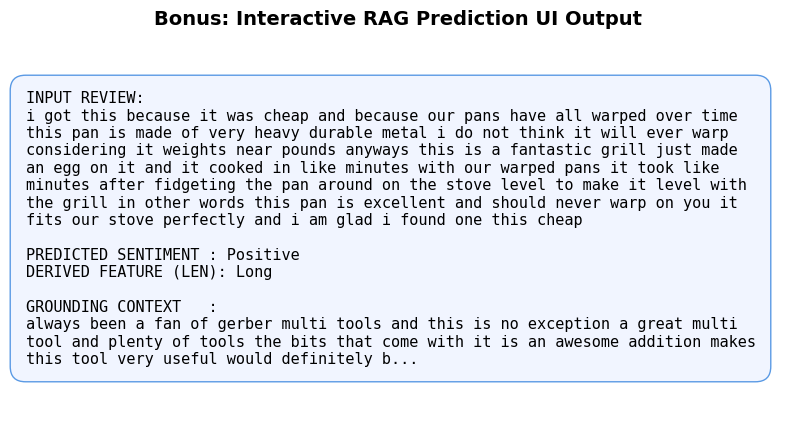

  Interactive UI output saved → results\bonus_ui_output.png
\n************************************************************
INPUT REVIEW: i got this because it was cheap and because our pans have all warped over time this pan is made of very heavy durable metal i do not think it will ever warp considering it weights near pounds anyways this is a fantastic grill just made an egg on it and it cooked in like minutes with our warped pans it took like minutes after fidgeting the pan around on the stove level to make it level with the grill in other words this pan is excellent and should never warp on you it fits our stove perfectly and i am glad i found one this cheap
PREDICTED SENTIMENT: Positive
DERIVED FEATURE (LEN): Long
GROUNDING CONTEXT: always been a fan of gerber multi tools and this is no exception a great multi tool and plenty of tools the bits that come with it is an awesome addition makes this tool very useful would definitely buy it again have not had any problems with my tool a

In [ ]:
import textwrap

sample_text =test_raw[10]['text'] #Ensuring sample_text is defined
ids_ui =torch.tensor(vocab.encode(sample_text)).to(DEVICE).unsqueeze(0)
with torch.no_grad():
    s_p, l_p, emb_ui =model_a(ids_ui)
ctx_ui = retrieve_top_k(emb_ui[0],k=1)

#Mapping predicted indices to human-readable labels for the UI summary
s_label =['Negative','Neutral','Positive'][torch.argmax(s_p).item()]
l_label =['Short','Medium','Long'][torch.argmax(l_p).item()]

#Building a text-based summary figure - Increased height to (10, 5) to prevent squashing
fig_ui,ax_ui =plt.subplots(figsize=(10, 5)) 
ax_ui.axis('off')

#Wrapping the text so it doesn't run off the screen
wrapped_review =textwrap.fill(sample_text, width=80)
wrapped_context =textwrap.fill(ctx_ui[0], width=80)

summary=(
    f"INPUT REVIEW:\n{wrapped_review}\n\n"
    f"PREDICTED SENTIMENT : {s_label}\n"
    f"DERIVED FEATURE (LEN): {l_label}\n\n"
    f"GROUNDING CONTEXT   :\n{wrapped_context[:200]}..."
)

#Added multialignment='left' and adjusted position
ax_ui.text(0.02,0.9,summary, transform=ax_ui.transAxes,
           fontsize=11, verticalalignment='top', family='monospace',
           bbox=dict(boxstyle='round,pad=1', facecolor='#f0f4ff', alpha=0.9, edgecolor='#4a90e2'))

ax_ui.set_title('Bonus: Interactive RAG Prediction UI Output', fontsize=14, fontweight='bold', pad=20)

#Removed tight_layout to avoid the margin error
#Saving the UI output figure to the results directory
ui_save_path =RESULTS_DIR / 'bonus_ui_output.png'
fig_ui.savefig(ui_save_path, dpi=150, bbox_inches='tight')
plt.show()

print(f"  Interactive UI output saved → {ui_save_path}")

#Also printing the same information in the console for quick reference
print(f"\\n{'*'*60}")
print(f"INPUT REVIEW: {sample_text}")
print(f"PREDICTED SENTIMENT: {s_label}")
print(f"DERIVED FEATURE (LEN): {l_label}")
print(f"GROUNDING CONTEXT: {ctx_ui[0]}")
print(f"{'*'*60}\\n")
